# Experiment: Robustness Under Degradation
This notebook orchestrates the image classification robustness evaluation.
It loads CIFAR-10, applies degradations, evaluates a pre-trained ResNet-20 model, and visualizes the results.

In [1]:
import os
import torch
import torchvision
import torchvision.transforms as transforms
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import sys

# Ensure src modules can be imported
sys.path.append(os.path.abspath('..'))

from src.preprocessing import get_degradations
from src.model import load_model, predict
from src.evaluation import calculate_metrics

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [2]:
# 1. Download and Prepare Data
# Load CIFAR-10 test set
# CIFAR-10 images are 32x32. We load them as PIL images first for preprocessing.
transform_to_pil = transforms.Lambda(lambda x: x) # No-op, keep as PIL for now

testset = torchvision.datasets.CIFAR10(root='../data', train=False, download=True, transform=transform_to_pil)

# Sample a subset to keep the notebook fast (e.g., 1000 images)
subset_indices = range(1000)
test_subset = torch.utils.data.Subset(testset, subset_indices)

# Save manifest of the test subset as data/sample_data.csv
manifest = []
for i in subset_indices:
    _, label = testset[i]
    manifest.append({'image_index': i, 'true_label': label})

pd.DataFrame(manifest).to_csv('../data/sample_data.csv', index=False)
print("Saved data/sample_data.csv")

Saved data/sample_data.csv


In [3]:
# 2. Load Model
model = load_model()
model = model.to(device)

# Standard normalization for CIFAR-10 models
normalize = transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2023, 0.1994, 0.2010])
to_tensor = transforms.ToTensor()

def preprocess_for_model(pil_image):
    tensor = to_tensor(pil_image)
    return normalize(tensor)

Downloading: "https://github.com/chenyaofo/pytorch-cifar-models/zipball/master" to C:\Users\Asus/.cache\torch\hub\master.zip


Downloading: "https://github.com/chenyaofo/pytorch-cifar-models/releases/download/resnet/cifar10_resnet20-4118986f.pt" to C:\Users\Asus/.cache\torch\hub\checkpoints\cifar10_resnet20-4118986f.pt


  0%|          | 0.00/1.09M [00:00<?, ?B/s]

 23%|██▎       | 256k/1.09M [00:00<00:00, 1.85MB/s]

100%|██████████| 1.09M/1.09M [00:00<00:00, 4.87MB/s]

In [4]:
# 3. Define Degradation Pipeline and Run Inference
degradations = get_degradations()
severities = [0, 1, 2, 3, 4, 5] # 0 is clean

results = []
metrics_summary = []

for deg_name, deg_func in degradations.items():
    print(f"Running degradation: {deg_name}")
    
    for severity in severities:
        if deg_name == 'clean' and severity > 0:
            continue # Clean has no severity levels
            
        y_true = []
        y_pred = []
        confs = []
        
        for idx in tqdm(range(len(test_subset)), desc=f"Severity {severity}", leave=False):
            pil_img, label = test_subset[idx]
            
            # Apply degradation
            if deg_name != 'clean':
                deg_img = deg_func(pil_img, severity)
            else:
                deg_img = pil_img
                
            # Prepare for model
            input_tensor = preprocess_for_model(deg_img).unsqueeze(0) # Add batch dimension
            
            # Predict
            pred_class, conf = predict(model, device, input_tensor)
            
            y_true.append(label)
            y_pred.append(pred_class[0])
            confs.append(conf[0])
            
            # Save per-sample log
            results.append({
                'degradation': deg_name,
                'severity': severity,
                'image_index': subset_indices[idx],
                'true_label': label,
                'predicted_label': pred_class[0],
                'confidence': conf[0]
            })
            
        # Calculate metrics for this degradation & severity
        metrics = calculate_metrics(y_true, y_pred, confs)
        metrics['degradation'] = deg_name
        metrics['severity'] = severity
        metrics_summary.append(metrics)

Running degradation: blur


Severity 0:   0%|          | 0/1000 [00:00<?, ?it/s]

Severity 0:   1%|          | 10/1000 [00:00<00:10, 98.85it/s]

Severity 0:   4%|▍         | 42/1000 [00:00<00:04, 225.38it/s]

Severity 0:   8%|▊         | 75/1000 [00:00<00:03, 270.10it/s]

...

Severity 5:  82%|████████▏ | 817/1000 [00:02<00:00, 383.38it/s]

Severity 5:  86%|████████▌ | 856/1000 [00:02<00:00, 384.59it/s]

Severity 5:  90%|████████▉ | 895/1000 [00:02<00:00, 380.44it/s]

Severity 5:  93%|█████████▎| 934/1000 [00:02<00:00, 381.30it/s]

Severity 5:  97%|█████████▋| 973/1000 [00:02<00:00, 382.72it/s]

In [5]:
# 4. Save Results
results_df = pd.DataFrame(results)
results_df.to_csv('../results/results.csv', index=False)
print("Saved per-sample logs to results/results.csv")

summary_df = pd.DataFrame(metrics_summary)
# Reorder columns
summary_df = summary_df[['degradation', 'severity', 'accuracy', 'macro_f1', 'mean_confidence', 'confidence_accuracy_gap']]
summary_df.to_csv('../results/comparison_table.csv', index=False)
print("Saved aggregated metrics to results/comparison_table.csv")

Saved per-sample logs to results/results.csv
Saved aggregated metrics to results/comparison_table.csv


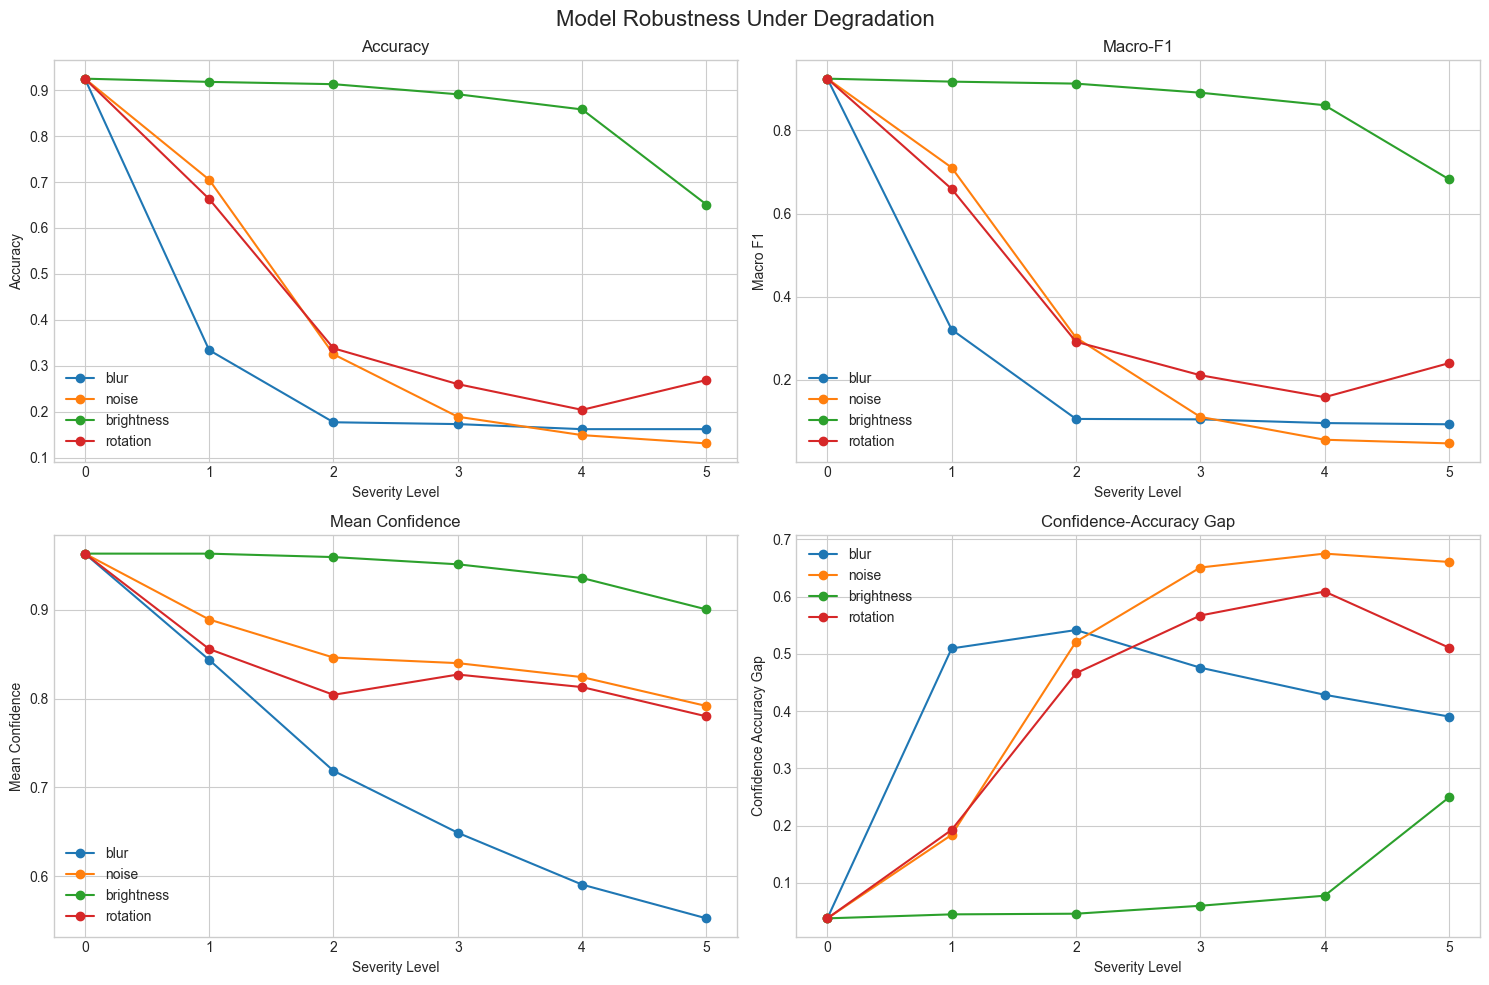

In [6]:
# 5. Visualizations
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Model Robustness Under Degradation', fontsize=16)

metrics_to_plot = ['accuracy', 'macro_f1', 'mean_confidence', 'confidence_accuracy_gap']
titles = ['Accuracy', 'Macro-F1', 'Mean Confidence', 'Confidence-Accuracy Gap']

for ax, metric, title in zip(axes.flatten(), metrics_to_plot, titles):
    for deg_name in degradations.keys():
        if deg_name == 'clean': continue
        
        subset = summary_df[summary_df['degradation'] == deg_name]
        ax.plot(subset['severity'], subset[metric], marker='o', label=deg_name)
        
    ax.set_title(title)
    ax.set_xlabel('Severity Level')
    ax.set_ylabel(metric.replace('_', ' ').title())
    ax.legend()

plt.tight_layout()
plt.savefig('../results/figures/metrics_trends.png', dpi=300)
plt.show()